# Bank Term Deposit Prediction
## Random Forest vs XGBoost — Final Model Comparison & Business Analysis

---

### Project Background

This project focuses on developing a machine learning solution for a European banking institution that conducts direct marketing campaigns through customer phone calls.

The primary objective is to predict whether a customer will subscribe to a **term deposit** and use the model results to improve the success rate of future marketing calls.

Two ensemble machine learning approaches were developed independently:

- **Random Forest** — Bagging-based ensemble model
- **XGBoost** — Boosting-based ensemble model

This notebook consolidates the saved results from both modeling experiments and provides a final comparison and business interpretation.

---

## Evaluation Strategy

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- 5-Fold Cross-Validation results
- Confusion Matrix
- Feature Importance

Because the target variable is highly imbalanced, **accuracy alone is not sufficient**. Precision, Recall and F1 Score are also considered when interpreting model performance.

---

## Important Comparison Note

The Random Forest and XGBoost experiments were originally developed using different train-test split sizes:

- **Random Forest:** 75% training / 25% testing
- **XGBoost:** 70% training / 30% testing

Therefore, their holdout-test metrics provide a useful model comparison, but they should not be interpreted as a perfectly controlled head-to-head experiment on identical test observations.

The original model training and tuning processes are not rerun in this notebook. Instead, this notebook uses the **saved results from the completed Random Forest and XGBoost experiments** for final comparative and business analysis.

# 1. Dataset Overview

The dataset contains customer information collected during a direct marketing campaign conducted by a European banking institution.

### Target Variable

**`y` — Term Deposit Subscription**

- `0` = Customer did not subscribe
- `1` = Customer subscribed

The original dataset contains **40,000 customer records**.

Before comparing the machine learning models, it is important to understand the distribution of the target variable because a strong class imbalance can make accuracy alone misleading.

Target Variable Distribution
-----------------------------------
Subscription  Count  Percentage
          No  37104       92.76
         Yes   2896        7.24


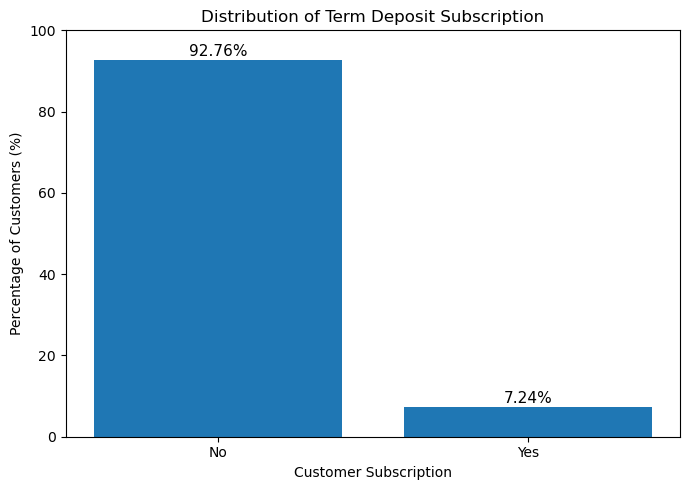

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Target distribution from the original dataset
target_distribution = pd.DataFrame({
    "Subscription": ["No", "Yes"],
    "Count": [37104, 2896]
})

target_distribution["Percentage"] = (
    target_distribution["Count"] /
    target_distribution["Count"].sum() * 100
)

print("Target Variable Distribution")
print("-" * 35)
print(target_distribution.to_string(index=False))

# Visualization
plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_distribution["Subscription"],
    target_distribution["Percentage"]
)

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Customer Subscription")
plt.ylabel("Percentage of Customers (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, target_distribution["Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Insight — Target Class Distribution

- The dataset is **highly imbalanced**.
- Approximately **92.76%** of customers did not subscribe to the term deposit.
- Only approximately **7.24%** of customers subscribed.
- Therefore, a model could achieve high accuracy simply by predicting most customers as non-subscribers.
- For this reason, **Precision, Recall, F1 Score and ROC-AUC** are considered alongside Accuracy when comparing Random Forest and XGBoost.
- This is particularly important for the business objective because the bank is interested in identifying the relatively small group of customers who are more likely to subscribe.

### Connection to the Business Questions

This class distribution directly affects two project questions:

**Can the model achieve at least 81% accuracy?**  
Accuracy will be checked against the required 81% benchmark, but it will not be used as the only measure of model quality.

**Can we identify customers who are more likely to buy the product?**  
The positive class represents only a small portion of the customer base. Therefore, the selected model must demonstrate an ability to identify subscribers rather than simply predicting the majority class.

# 2. Random Forest Model Results

Random Forest was used as the **bagging-based ensemble approach** for this classification problem.

Multiple Random Forest configurations were evaluated, including:

- Regular Random Forest
- Class-weight balanced Random Forest
- Hyperparameter tuning using GridSearchCV
- SMOTE-based Random Forest experiments

The purpose of these experiments was not only to maximize overall accuracy, but also to improve the model's ability to identify the minority class — customers who actually subscribed to the term deposit.

The following results are reconstructed from the saved outputs of the completed Random Forest notebook. The model is **not retrained** in this comparison notebook.

In [2]:
rf_results = pd.DataFrame({
    "Model": [
        "Regular Random Forest",
        "Balanced RF - Grid 1",
        "Balanced RF - Grid 2",
        "Balanced RF - Grid 3",
        "SMOTE RF - Ratio 0.5",
        "Tuned SMOTE RF"
    ],
    
    "Accuracy": [
        0.9316,
        0.9126,
        0.9096,
        0.9104,
        0.9273,
        0.9247
    ],
    
    "Precision": [
        0.5680,
        0.4324,
        0.4224,
        0.4238,
        0.4971,
        0.4771
    ],
    
    "Recall": [
        0.2307,
        0.6630,
        0.6768,
        0.6602,
        0.3536,
        0.4171
    ],
    
    "F1 Score": [
        0.3281,
        0.5234,
        0.5202,
        0.5162,
        0.4132,
        0.4451
    ],
    
    "ROC-AUC": [
        0.9042,
        0.9175,
        0.9169,
        0.9174,
        0.9080,
        0.9152
    ]
})

print("Random Forest Experiment Results")
print("-" * 95)

display(
    rf_results.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC-AUC": "{:.4f}"
    })
)

Random Forest Experiment Results
-----------------------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Regular Random Forest,93.16%,56.80%,23.07%,32.81%,0.9042
1,Balanced RF - Grid 1,91.26%,43.24%,66.30%,52.34%,0.9175
2,Balanced RF - Grid 2,90.96%,42.24%,67.68%,52.02%,0.9169
3,Balanced RF - Grid 3,91.04%,42.38%,66.02%,51.62%,0.9174
4,SMOTE RF - Ratio 0.5,92.73%,49.71%,35.36%,41.32%,0.9080
5,Tuned SMOTE RF,92.47%,47.71%,41.71%,44.51%,0.9152


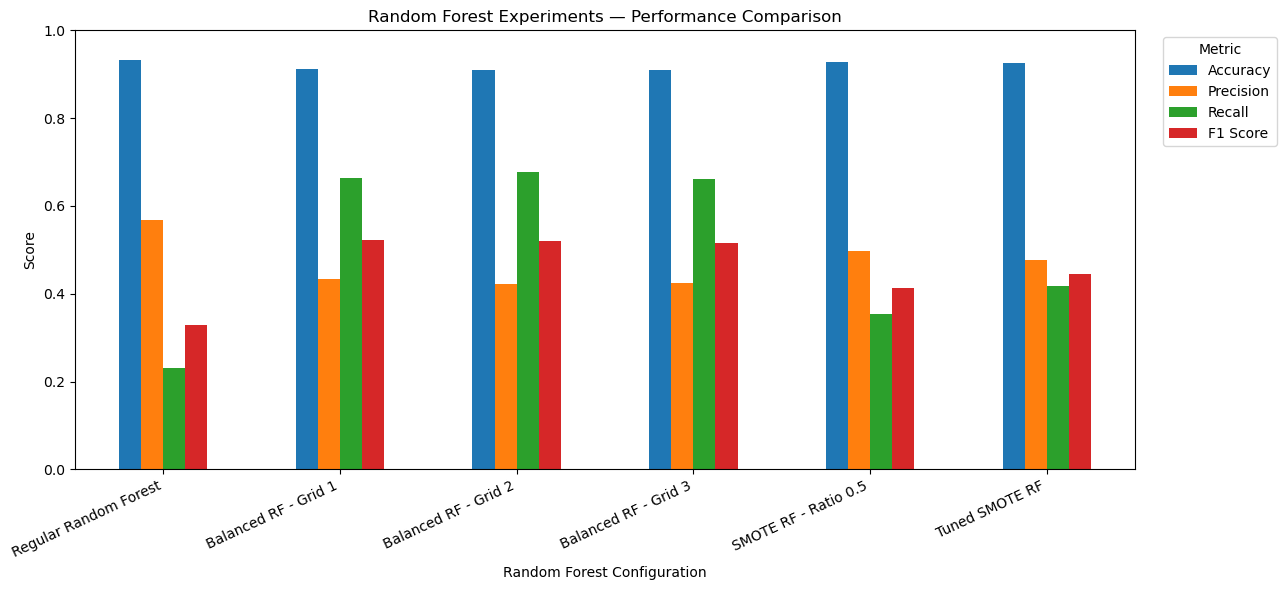

In [3]:
rf_plot = rf_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = rf_plot.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Random Forest Experiments — Performance Comparison")
plt.xlabel("Random Forest Configuration")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Random Forest Results — Key Insights

- All evaluated Random Forest configurations achieved **more than the required 81% accuracy**.
- The **Regular Random Forest** produced the highest overall accuracy and precision among the listed RF experiments, but its recall was relatively low. This means that many actual subscribers were missed.
- Applying class balancing substantially increased the model's ability to detect subscribers.
- **Balanced RF Grid 1** achieved an F1 Score of approximately **52.34%**, with Recall of approximately **66.30%**.
- **Balanced RF Grid 2** produced the highest Recall among the listed Random Forest experiments at approximately **67.68%**, but with slightly lower Precision and F1 Score.
- SMOTE improved minority-class detection compared with the regular model, but the listed SMOTE experiments did not outperform the strongest class-weight-balanced Random Forest models on F1 Score.
- These results demonstrate the trade-off between **Precision and Recall** caused by the strong class imbalance.

### Interpretation

For this business problem, maximizing Accuracy alone would not be sufficient.

The Regular Random Forest is more conservative when predicting a subscription. This helps Precision, but it misses many customers who actually subscribe.

The balanced Random Forest models identify substantially more potential subscribers, making them more useful for the business objective of finding customers who are more likely to purchase the term deposit.

Among the listed Random Forest experiments, **Balanced RF Grid 1 provides a strong balance between Precision, Recall and F1 Score** and will therefore be carried forward as a key Random Forest candidate for the final model comparison.

# 3. XGBoost Model Results

XGBoost was used as the **boosting-based ensemble approach** for the term-deposit classification problem.

The modeling process included:

- Baseline XGBoost
- Multiple GridSearchCV experiments
- Class-imbalance handling using `scale_pos_weight`
- Optuna-based hyperparameter optimization

The objective was to improve the identification of customers who subscribe to the term deposit while maintaining strong overall predictive performance.

The results presented below are taken from the saved outputs of the completed XGBoost experiment. The models are **not retrained** in this comparison notebook.

In [4]:
xgb_results = pd.DataFrame({
    "Model": [
        "XGBoost Baseline",
        "XGBoost Grid 1",
        "XGBoost Grid 2",
        "XGBoost Grid 3",
        "XGBoost Grid 4"
    ],

    "Accuracy": [
        0.9322,
        0.9322,
        0.9339,
        0.9334,
        0.9195
    ],

    "Precision": [
        0.5558,
        0.5607,
        0.5809,
        0.5742,
        0.4591
    ],

    "Recall": [
        0.3153,
        0.2923,
        0.3142,
        0.3119,
        0.6260
    ],

    "F1 Score": [
        0.4023,
        0.3843,
        0.4078,
        0.4042,
        0.5297
    ],

    "ROC-AUC": [
        0.9177,
        0.9254,
        0.9253,
        0.9245,
        0.9256
    ]
})

print("XGBoost Experiment Results")
print("-" * 95)

display(
    xgb_results.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC-AUC": "{:.4f}"
    })
)

XGBoost Experiment Results
-----------------------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost Baseline,93.22%,55.58%,31.53%,40.23%,0.9177
1,XGBoost Grid 1,93.22%,56.07%,29.23%,38.43%,0.9254
2,XGBoost Grid 2,93.39%,58.09%,31.42%,40.78%,0.9253
3,XGBoost Grid 3,93.34%,57.42%,31.19%,40.42%,0.9245
4,XGBoost Grid 4,91.95%,45.91%,62.60%,52.97%,0.9256


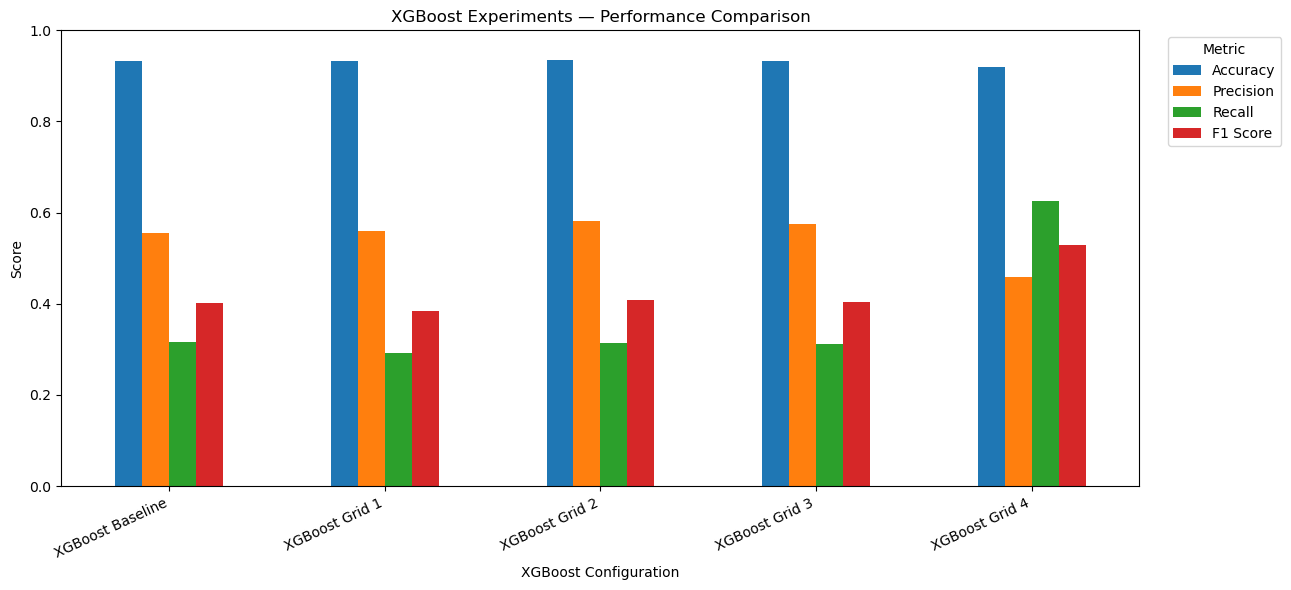

In [5]:
xgb_plot = xgb_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
]

ax = xgb_plot.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("XGBoost Experiments — Performance Comparison")
plt.xlabel("XGBoost Configuration")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### XGBoost Results — Key Insights

- All evaluated XGBoost configurations exceeded the project's required **81% accuracy benchmark**.
- **XGBoost Grid 2** achieved the highest Accuracy and Precision among the listed XGBoost test results, with approximately **93.39% Accuracy** and **58.09% Precision**.
- However, Grid 2 identified only about **31.42% of the actual subscribers**, as reflected by its Recall.
- Introducing stronger class-imbalance handling in **XGBoost Grid 4** produced a major improvement in minority-class detection.
- Grid 4 achieved approximately **62.60% Recall**, meaning it identified substantially more actual subscribers than the other listed XGBoost configurations.
- Grid 4 also achieved the highest listed XGBoost **F1 Score of approximately 52.97%** and **ROC-AUC of approximately 0.9256**.
- The improvement in Recall came with a reduction in Precision and overall Accuracy, demonstrating the expected trade-off when the model is encouraged to identify more minority-class customers.

### Interpretation

The results show why Accuracy alone should not determine the final model.

Grid 2 achieves very high Accuracy and stronger Precision, but it misses a large proportion of actual subscribers.

Grid 4 provides a more balanced result for the business objective. It identifies substantially more customers who actually subscribe while still maintaining approximately **91.95% Accuracy**, which remains well above the required 81% benchmark.

Therefore, **XGBoost Grid 4 is an important candidate for the final Random Forest vs XGBoost comparison**, particularly when subscriber identification is considered alongside overall Accuracy.

# 4. Five-Fold Cross-Validation Analysis

The project success criterion requires the model to achieve at least **81% accuracy using 5-fold cross-validation and report the average performance score**.

Both Random Forest and XGBoost experiments used 5-fold cross-validation during model tuning.

However, an important distinction must be made between:

- **Cross-Validation Accuracy**
- **Cross-Validation F1 Score**
- **Holdout Test Accuracy**

The saved tuning outputs primarily report **F1 Score as the optimization metric** for the strongest tuned models. Therefore, these CV F1 scores must not be incorrectly presented as CV Accuracy.

The available saved cross-validation results are summarized below.

In [6]:
cv_results = pd.DataFrame({
    "Model": [
        "Random Forest - Grid 1",
        "Random Forest - Grid 3",
        "XGBoost - Grid 1",
        "XGBoost - Grid 2",
        "XGBoost - Grid 3",
        "XGBoost - Grid 4",
        "XGBoost - Optuna Study 1"
    ],

    "CV Metric": [
        "F1", "F1", "F1", "F1", "F1", "F1", "F1"
    ],

    "Mean 5-Fold CV Score": [
        0.5196,
        0.5244,
        0.4028,
        0.4110,
        0.4115,
        0.5305,
        0.5315
    ]
})

display(
    cv_results.style.format({
        "Mean 5-Fold CV Score": "{:.4f}"
    })
)

,Model,CV Metric,Mean 5-Fold CV Score
0,Random Forest - Grid 1,F1,0.5196
1,Random Forest - Grid 3,F1,0.5244
2,XGBoost - Grid 1,F1,0.4028
3,XGBoost - Grid 2,F1,0.4110
4,XGBoost - Grid 3,F1,0.4115
5,XGBoost - Grid 4,F1,0.5305
6,XGBoost - Optuna Study 1,F1,0.5315


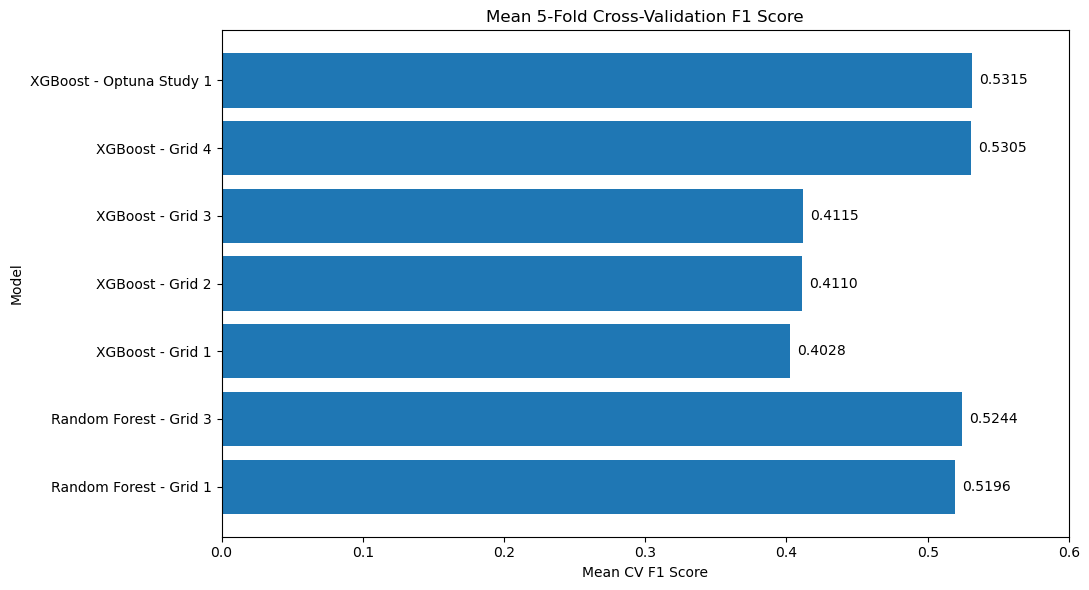

In [7]:
plt.figure(figsize=(11, 6))

bars = plt.barh(
    cv_results["Model"],
    cv_results["Mean 5-Fold CV Score"]
)

plt.title("Mean 5-Fold Cross-Validation F1 Score")
plt.xlabel("Mean CV F1 Score")
plt.ylabel("Model")
plt.xlim(0, 0.60)

for bar, value in zip(
    bars,
    cv_results["Mean 5-Fold CV Score"]
):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Five-Fold Cross-Validation Insights

- Five-fold cross-validation was used during model tuning to evaluate model performance across multiple training-validation partitions.
- The saved tuning results primarily contain **mean CV F1 Score**, rather than mean CV Accuracy.
- Among the listed Random Forest tuning experiments, **Random Forest Grid 3** achieved a mean CV F1 Score of approximately **0.5244**.
- **XGBoost Grid 4** improved the mean CV F1 Score to approximately **0.5305**.
- The saved **XGBoost Optuna Study 1** optimization produced a slightly higher mean CV F1 Score of approximately **0.5315**.
- The relatively close CV F1 results of the strongest Random Forest and XGBoost configurations indicate that both approaches were competitive in identifying the minority subscription class.

### Success-Metric Interpretation

The holdout-test results of the evaluated models exceed the project's **81% accuracy target**.

However, the saved model-tuning outputs shown above report **5-fold CV F1 Score**, not 5-fold CV Accuracy.

Therefore, this notebook does **not** incorrectly claim that the 81% cross-validation accuracy requirement was directly verified from these F1 values.

Instead, the analysis distinguishes between:

- the documented 5-fold cross-validation F1 performance used during tuning, and
- the documented holdout-test accuracy used for final model evaluation.

This distinction ensures that the reported results remain consistent with the saved experimental evidence.

# 5. Final Model Comparison — Random Forest vs XGBoost

After evaluating the experiments within each model family, two strong balanced candidates are carried forward for direct comparison:

- **Random Forest — Balanced Grid 1**
- **XGBoost — Grid 4**

These models are particularly relevant to the business objective because they provide a stronger balance between identifying actual subscribers and maintaining high overall predictive performance.

> **Comparison Limitation:**  
> The original Random Forest and XGBoost experiments used different train-test split sizes. Therefore, the following holdout comparison should be interpreted as a comparison of the documented experimental results rather than a perfectly controlled evaluation on identical test observations.

In [8]:
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Balanced Grid 1",
        "XGBoost - Grid 4"
    ],

    "Accuracy": [
        0.9126,
        0.9195
    ],

    "Precision": [
        0.4324,
        0.4591
    ],

    "Recall": [
        0.6630,
        0.6260
    ],

    "F1 Score": [
        0.5234,
        0.5297
    ],

    "ROC-AUC": [
        0.9175,
        0.9256
    ],

    "Mean CV F1": [
        0.5196,
        0.5305
    ]
})

display(
    final_comparison.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "ROC-AUC": "{:.4f}",
        "Mean CV F1": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Mean CV F1
0,Random Forest - Balanced Grid 1,91.26%,43.24%,66.30%,52.34%,0.9175,0.5196
1,XGBoost - Grid 4,91.95%,45.91%,62.60%,52.97%,0.9256,0.5305


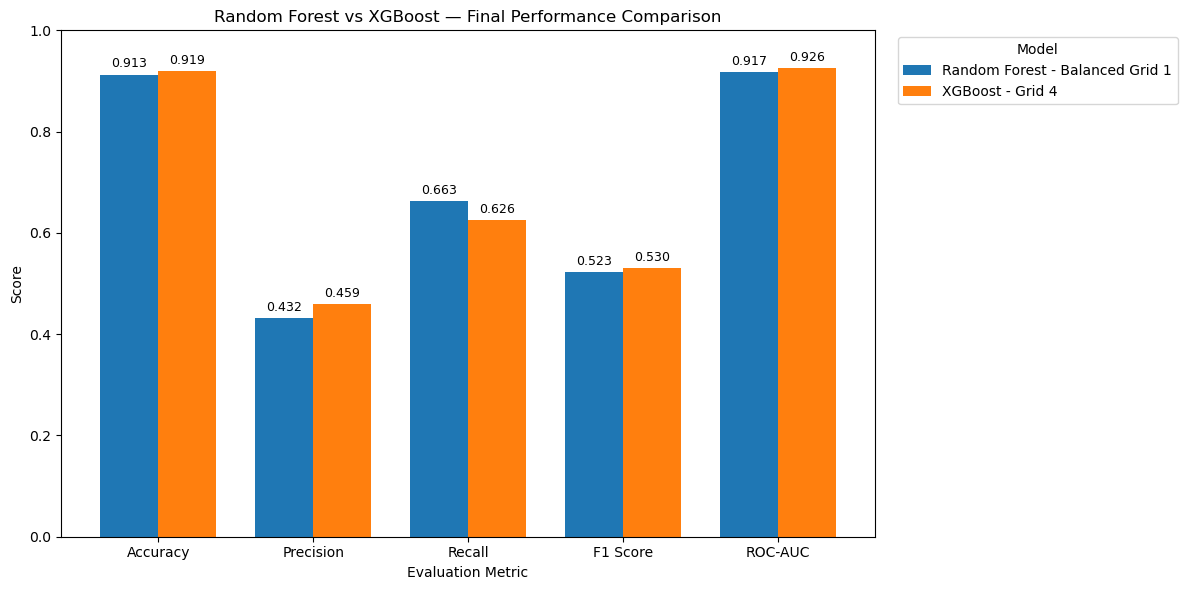

In [9]:
comparison_plot = final_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].T

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.75
)

plt.title("Random Forest vs XGBoost — Final Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Final Model Comparison — Key Findings

- **Accuracy:** XGBoost Grid 4 achieved approximately **91.95% Accuracy**, compared with **91.26%** for Random Forest Balanced Grid 1. Both models exceeded the project's 81% holdout-accuracy benchmark.

- **Precision:** XGBoost achieved approximately **45.91% Precision**, compared with **43.24%** for Random Forest. In the documented experiments, XGBoost therefore produced a higher proportion of correct predictions among customers predicted to subscribe.

- **Recall:** Random Forest achieved approximately **66.30% Recall**, compared with **62.60%** for XGBoost. Random Forest therefore detected a larger proportion of the actual subscribers in its documented holdout evaluation.

- **F1 Score:** XGBoost achieved a slightly higher F1 Score of approximately **52.97%**, compared with **52.34%** for Random Forest. This indicates a slightly stronger balance between Precision and Recall in the documented results.

- **ROC-AUC:** XGBoost achieved approximately **0.9256**, compared with **0.9175** for Random Forest, indicating stronger overall class-separation performance in the documented experiments.

- **5-Fold CV F1:** XGBoost Grid 4 achieved approximately **0.5305**, while Random Forest Grid 1 achieved approximately **0.5196**.

### Model Selected for the Remaining Business Analysis

For the remaining business interpretation, **XGBoost Grid 4 is selected as the primary reference model** because its documented results provide:

- Higher Accuracy
- Higher Precision
- Slightly higher F1 Score
- Higher ROC-AUC
- Higher mean 5-fold CV F1 Score

Random Forest remains important because it achieved higher Recall and identified a larger proportion of actual subscribers in its documented holdout experiment.

The selection of XGBoost is therefore based on the overall balance of the available documented metrics rather than Accuracy alone.

> Because the two original experiments used different holdout samples, this selection should be interpreted in the context of the available saved experimental results rather than as a perfectly controlled same-sample benchmark.

# 6. What Factors Influence Term Deposit Subscription?

After selecting XGBoost Grid 4 as the primary model for business interpretation, the next objective is to understand **which features were most important to the model's predictions**.

Feature importance helps identify the variables that contributed most strongly to the model's decision-making process.

> **Important:** Feature importance measures predictive contribution, not causality.  
> A highly important feature does not necessarily cause a customer to subscribe, and feature importance alone does not indicate whether a category increases or decreases the probability of subscription.

In [10]:
feature_importance = pd.DataFrame({
    "Feature": [
        "Duration",
        "Week 3",
        "Age 60+",
        "Quarter Q3",
        "No Housing Loan",
        "Quarter Q1",
        "Quarter Q4",
        "Age 18-30",
        "Week 4",
        "Week 2",
        "Married",
        "Tertiary Education",
        "Quarter Q2",
        "No Personal Loan",
        "Student",
        "Primary Education",
        "Week 1",
        "Single",
        "Blue-collar",
        "Balance 2001-5000"
    ],

    "Importance": [
        0.1332,
        0.0898,
        0.0682,
        0.0671,
        0.0650,
        0.0560,
        0.0460,
        0.0380,
        0.0361,
        0.0313,
        0.0287,
        0.0283,
        0.0280,
        0.0245,
        0.0197,
        0.0189,
        0.0168,
        0.0152,
        0.0147,
        0.0142
    ]
})

display(
    feature_importance.style.format({
        "Importance": "{:.4f}"
    })
)

,Feature,Importance
0,Duration,0.1332
1,Week 3,0.0898
2,Age 60+,0.0682
3,Quarter Q3,0.0671
4,No Housing Loan,0.0650
5,Quarter Q1,0.0560
6,Quarter Q4,0.0460
7,Age 18-30,0.0380
8,Week 4,0.0361
9,Week 2,0.0313


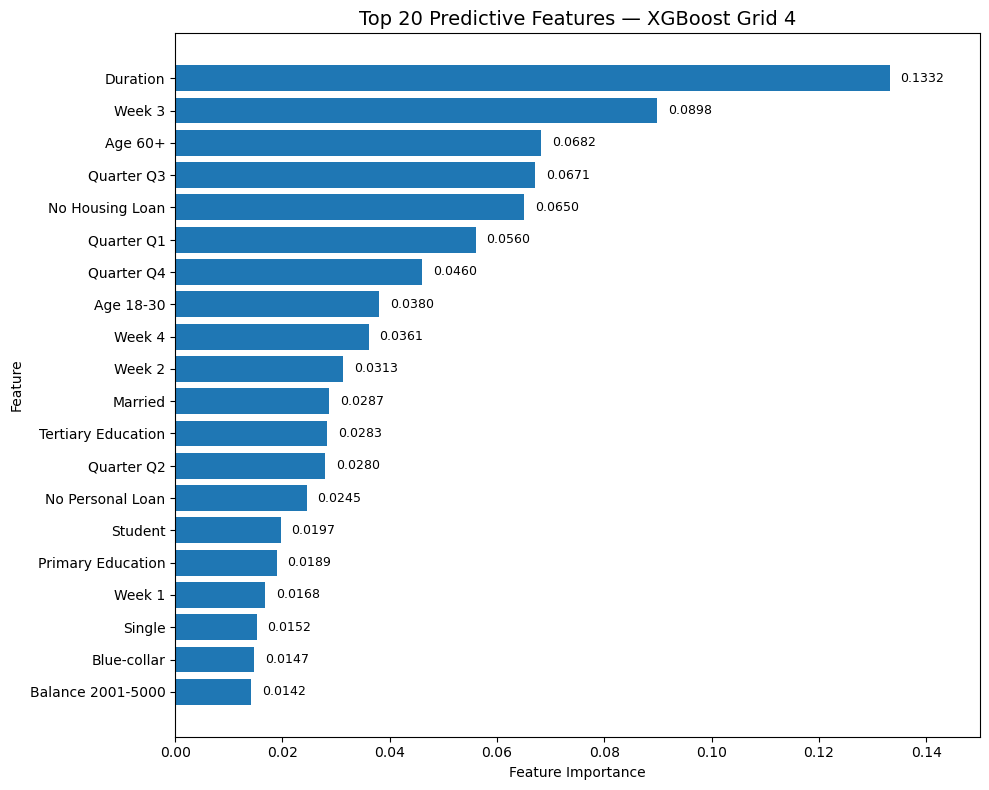

In [11]:
feature_plot = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    feature_plot["Feature"],
    feature_plot["Importance"]
)

plt.title(
    "Top 20 Predictive Features — XGBoost Grid 4",
    fontsize=14
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for bar, value in zip(
    bars,
    feature_plot["Importance"]
):
    plt.text(
        value + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center",
        fontsize=9
    )

plt.xlim(0, 0.15)
plt.tight_layout()
plt.show()

### Feature Importance — Key Findings

The XGBoost model indicates that several groups of variables are important for predicting term-deposit subscription.

#### 1. Call Duration

- **Duration is the most important individual feature**, with an importance score of approximately **0.1332**.
- This indicates that information related to call duration contributed strongly to the model's predictions.
- However, duration is known only during or after a customer call.
- Therefore, it is useful for explaining historical campaign outcomes but is limited for deciding **which customers should be contacted before the call begins**.

#### 2. Campaign Timing

Several timing-related variables appear among the most important features:

- Week 3
- Quarter Q3
- Quarter Q1
- Quarter Q4
- Week 4
- Week 2
- Quarter Q2
- Week 1

This indicates that the **timing of customer contact is an important component of the model's predictions**.

#### 3. Customer Age

Two age groups appear prominently:

- Age 60+
- Age 18–30

This suggests that customer age segmentation provides useful predictive information to the model.

#### 4. Existing Financial Commitments

Important financial-status variables include:

- No Housing Loan
- No Personal Loan
- Balance between 2001 and 5000

These variables indicate that a customer's existing financial situation contributes useful information when predicting subscription behavior.

#### 5. Customer Profile

Other important customer characteristics include:

- Marital status
- Education level
- Student occupation
- Blue-collar occupation

These variables show that demographic and occupational characteristics also contribute to the model's predictions.

### Business Question: What Makes Customers Buy the Product?

Based on the XGBoost model, term-deposit subscription is associated with a combination of:

1. **Customer engagement during the call** — represented strongly by call duration.
2. **Campaign timing** — week and quarter variables contribute substantially to predictions.
3. **Customer age profile** — particularly the 60+ and 18–30 groups.
4. **Existing financial commitments** — housing-loan and personal-loan status.
5. **Customer financial position** — including account-balance groups.
6. **Customer demographic profile** — including occupation, marital status and education.

### Business Interpretation

The results suggest that term-deposit marketing should not rely on a single customer characteristic.

Instead, the bank should consider a combination of:

**Customer Profile + Financial Situation + Campaign Timing + Customer Engagement**

when evaluating potential subscription opportunities.

> These findings describe variables that were important to the predictive model. They should not be interpreted as proof that these variables directly cause customers to purchase a term deposit.

# 7. Customer Segmentation — Who Should the Bank Prioritize?

One of the main business objectives is to identify customer groups that may deserve greater attention during future marketing campaigns.

The selected XGBoost model indicates that customer characteristics, financial status and campaign timing all contribute to subscription predictions.

Important segmentation variables include:

- Age Group
- Occupation
- Education
- Marital Status
- Account Balance
- Housing Loan Status
- Personal Loan Status
- Campaign Week
- Campaign Quarter

However, **feature importance does not indicate direction**.

For example, the presence of `Age 60+` among the important features tells us that this age category was useful to the model, but feature importance alone does not prove that customers aged 60+ have a higher subscription rate.

Therefore, customer prioritization should distinguish between:

1. **Segments that are important to the predictive model**
2. **Segments that can practically be used before making a marketing call**
3. **Call-related information that becomes available only after contact begins**

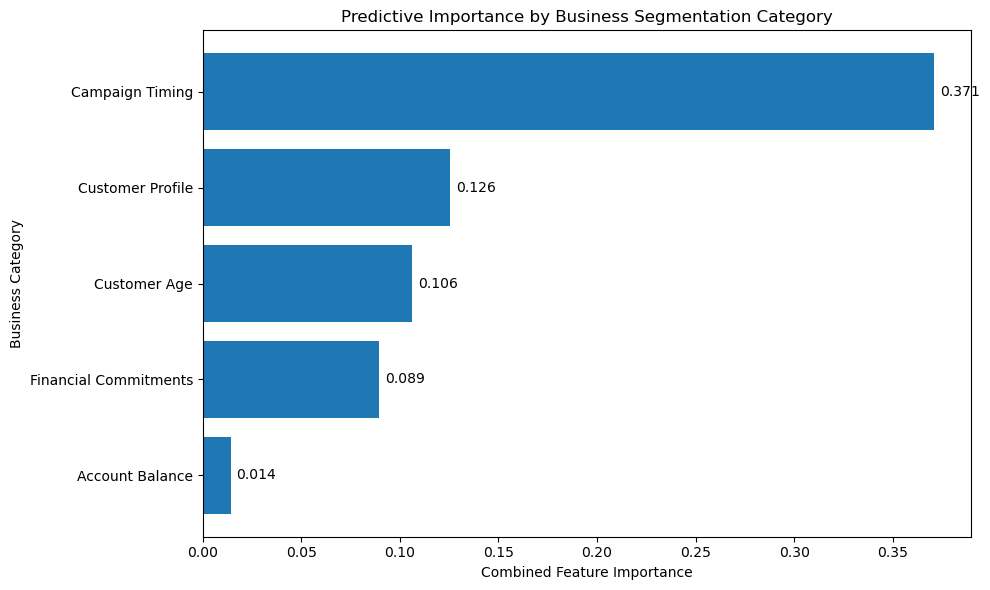

In [12]:
segment_categories = pd.DataFrame({
    "Category": [
        "Campaign Timing",
        "Customer Age",
        "Financial Commitments",
        "Customer Profile",
        "Account Balance"
    ],

    "Combined Importance": [
        # Week 3 + Q3 + Q1 + Q4 + Week 4 + Week 2 + Q2 + Week 1
        0.0898 + 0.0671 + 0.0560 + 0.0460 +
        0.0361 + 0.0313 + 0.0280 + 0.0168,

        # Age 60+ + Age 18-30
        0.0682 + 0.0380,

        # No Housing Loan + No Personal Loan
        0.0650 + 0.0245,

        # Married + Tertiary + Student + Primary + Single + Blue-collar
        0.0287 + 0.0283 + 0.0197 +
        0.0189 + 0.0152 + 0.0147,

        # Balance 2001-5000
        0.0142
    ]
})

segment_categories = segment_categories.sort_values(
    "Combined Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    segment_categories["Category"],
    segment_categories["Combined Importance"]
)

plt.title(
    "Predictive Importance by Business Segmentation Category"
)

plt.xlabel("Combined Feature Importance")
plt.ylabel("Business Category")

for bar, value in zip(
    bars,
    segment_categories["Combined Importance"]
):
    plt.text(
        value + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Customer Segmentation Findings

The grouped feature-importance analysis provides several useful observations.

#### 1. Campaign Timing

Campaign timing has a strong combined contribution to the model.

Important timing variables include:

- Week 3
- Week 4
- Week 2
- Week 1
- Q1
- Q2
- Q3
- Q4

This suggests that **when the bank contacts customers should be considered when planning future campaigns**.

The importance values alone, however, do not identify which week or quarter has the highest conversion rate.

---

#### 2. Customer Age

Age-related variables also contribute strongly to prediction.

The model particularly uses information associated with:

- Age 60+
- Age 18–30

This indicates that customer age is useful for segmentation and should be considered when developing targeted marketing strategies.

---

#### 3. Financial Commitments

Housing-loan and personal-loan information contributes to the model's predictions.

This suggests that the customer's existing financial obligations contain useful information for distinguishing potential subscribers.

---

#### 4. Customer Profile

Occupation, marital status and education also contribute predictive information.

Examples appearing among the important features include:

- Student
- Blue-collar
- Married
- Single
- Tertiary education
- Primary education

This supports the use of demographic and occupational segmentation rather than applying the same marketing strategy to every customer.

---

#### 5. Account Balance

Customer balance information also contributes to prediction.

The balance group **2001–5000** appears among the important XGBoost features, indicating that financial position provides useful predictive information.

### Business Question: Which Customer Segments Should Be Prioritized?

Based on the available model evidence, the bank should use a **multi-factor targeting strategy** rather than selecting customers based on only one characteristic.

The strongest pre-call segmentation areas identified by the model are:

1. **Campaign timing**
2. **Customer age**
3. **Housing and personal-loan status**
4. **Occupation, education and marital profile**
5. **Account balance**

A practical targeting system should combine these characteristics into a predicted subscription probability and prioritize customers with stronger model-predicted potential.

### Recommended Targeting Approach

Instead of using a rule such as:

> “Call every customer aged 60+”

the bank should use a combination such as:

> **Age + Financial Status + Occupation + Balance + Campaign Timing**

and allow the predictive model to combine these factors when estimating subscription probability.

This approach is more consistent with the machine-learning results because customer subscription behavior appears to depend on multiple interacting characteristics.

### Important Limitation

Call duration should **not** be used to decide which customers to call initially because duration is not known before the call takes place.

For a production system whose purpose is specifically **pre-call customer prioritization**, a future version of the model should therefore be trained and evaluated without `duration`.

# 8. Can We Predict Whether a Customer Will Subscribe?

The primary prediction objective is:

> **Predict whether a customer will subscribe to a term deposit (`Yes` or `No`).**

The selected XGBoost Grid 4 model achieved:

- **Accuracy:** 91.95%
- **Precision:** 45.91%
- **Recall:** 62.60%
- **F1 Score:** 52.97%
- **ROC-AUC:** 0.9256

These results show that the model can distinguish between subscribers and non-subscribers with strong overall classification performance.

Because the dataset is highly imbalanced, the model's ability to identify the positive class must also be examined through the confusion matrix.

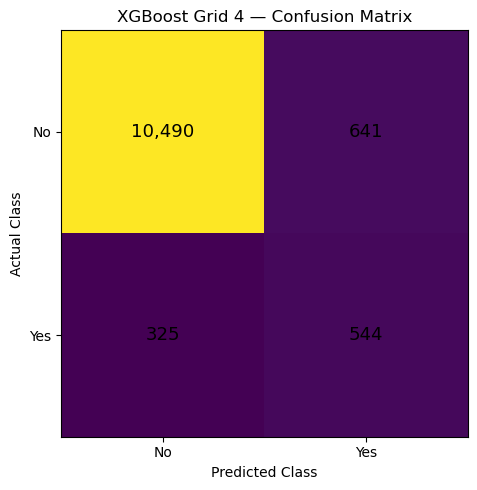

In [13]:
import numpy as np

# Saved confusion-matrix results from XGBoost Grid 4
xgb_cm = np.array([
    [10490, 641],
    [325, 544]
])

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(xgb_cm)

ax.set_title("XGBoost Grid 4 — Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["No", "Yes"])
ax.set_yticklabels(["No", "Yes"])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{xgb_cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=13
        )

plt.tight_layout()
plt.show()

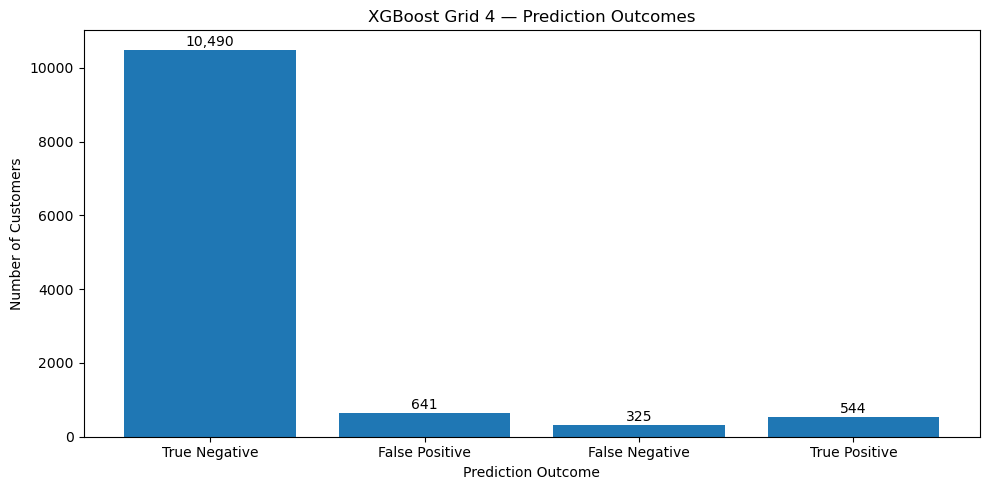

In [14]:
prediction_outcomes = pd.DataFrame({
    "Outcome": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],

    "Customers": [
        10490,
        641,
        325,
        544
    ]
})

plt.figure(figsize=(10, 5))

bars = plt.bar(
    prediction_outcomes["Outcome"],
    prediction_outcomes["Customers"]
)

plt.title("XGBoost Grid 4 — Prediction Outcomes")
plt.xlabel("Prediction Outcome")
plt.ylabel("Number of Customers")

for bar, value in zip(
    bars,
    prediction_outcomes["Customers"]
):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a practical explanation of the model's predictions.

#### True Negatives — 10,490 Customers

The model correctly predicted **10,490 customers who did not subscribe**.

This represents customers for whom the model successfully identified a negative subscription outcome.

---

#### True Positives — 544 Customers

The model correctly identified **544 actual subscribers**.

These are particularly important for the business because they represent customers whose positive subscription behavior was successfully detected by the model.

---

#### False Positives — 641 Customers

The model predicted that **641 customers would subscribe when they actually did not**.

From a business perspective, these customers could result in marketing calls that do not lead to a subscription.

---

#### False Negatives — 325 Customers

The model predicted that **325 customers would not subscribe even though they actually did**.

These cases represent missed subscription opportunities.

Reducing False Negatives can be important when the business objective is to identify as many potential buyers as possible.

### Business Question 1: Can We Predict Whether a Customer Will Subscribe?

**Yes — the model demonstrates useful predictive ability on the documented holdout evaluation.**

The selected XGBoost Grid 4 model achieved:

| Metric | Result |
|---|---:|
| Accuracy | 91.95% |
| Precision | 45.91% |
| Recall | 62.60% |
| F1 Score | 52.97% |
| ROC-AUC | 0.9256 |

### Interpretation

- The model correctly classified approximately **91.95% of the holdout observations overall**.
- It identified approximately **62.60% of the customers who actually subscribed**.
- When the model predicted a subscription, approximately **45.91% of those positive predictions were correct**.
- The ROC-AUC of approximately **0.9256** indicates strong ability to separate subscribers from non-subscribers across classification thresholds.
- The F1 Score of approximately **52.97%** reflects the balance between Precision and Recall for the minority subscriber class.

### Business Value

The model can help the bank move from a broad marketing strategy toward a more data-driven approach.

Instead of treating every customer as equally likely to subscribe, model predictions can be used to help identify customers with stronger predicted subscription potential.

However, the model should support marketing decisions rather than being interpreted as a guarantee that an individual customer will subscribe.

# 9. Which Features Should the Bank Focus On?

For practical marketing decisions, features should be separated based on **when they are available**.

### Pre-Call Features

These variables are available before contacting the customer:

- Age
- Job
- Marital Status
- Education
- Account Balance
- Housing Loan
- Personal Loan
- Campaign Timing

These features can help the bank decide **which customers to prioritize before making calls**.

### During-Call Feature

- Call Duration

Although call duration is the most important individual feature in the XGBoost model, it is not available before the call begins.

Therefore, it should not be the primary feature for pre-call customer targeting.

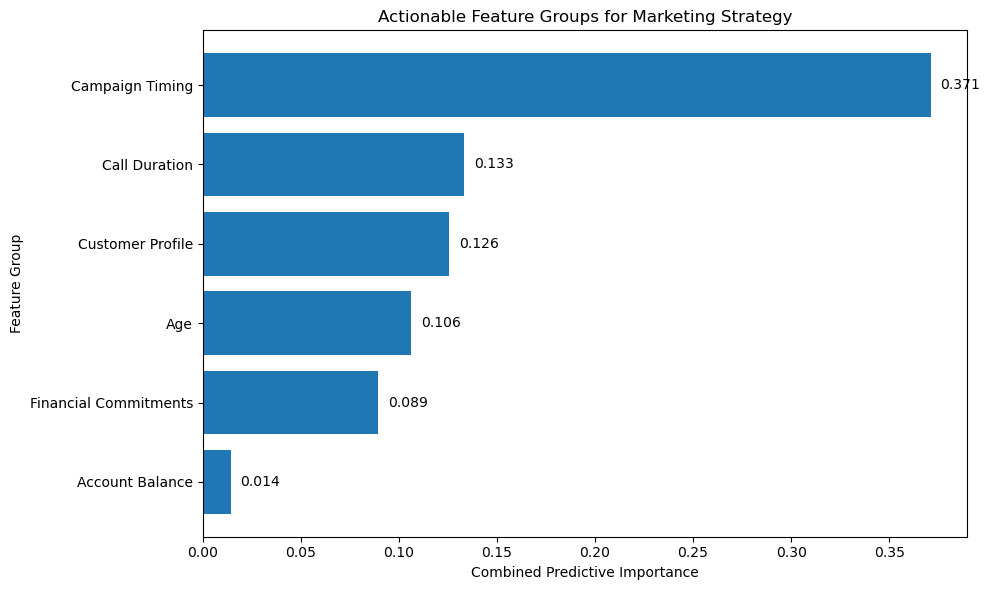

In [15]:
actionable_features = pd.DataFrame({
    "Feature Group": [
        "Campaign Timing",
        "Age",
        "Financial Commitments",
        "Customer Profile",
        "Account Balance",
        "Call Duration"
    ],
    
    "Usage": [
        "Pre-Call",
        "Pre-Call",
        "Pre-Call",
        "Pre-Call",
        "Pre-Call",
        "During Call"
    ],
    
    "Importance": [
        0.3711,
        0.1062,
        0.0895,
        0.1255,
        0.0142,
        0.1332
    ]
})

actionable_features = actionable_features.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    actionable_features["Feature Group"],
    actionable_features["Importance"]
)

plt.title("Actionable Feature Groups for Marketing Strategy")
plt.xlabel("Combined Predictive Importance")
plt.ylabel("Feature Group")

for bar, value in zip(
    bars,
    actionable_features["Importance"]
):
    plt.text(
        value + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Key Insights

- **Campaign timing** provides substantial predictive information and can be used before contacting customers.
- **Customer profile** such as occupation, education and marital status also contributes to prediction.
- **Age** is another useful customer-segmentation variable.
- **Housing loan and personal loan status** provide information about existing financial commitments.
- **Account balance** adds additional information about the customer's financial profile.
- **Call duration** is highly important, but it is only known after the call has started.

### Recommendation

For **pre-call targeting**, the bank should primarily focus on:

**Campaign Timing + Customer Profile + Age + Financial Commitments + Account Balance**

Call duration can be useful for understanding campaign outcomes, but it should not be relied upon when deciding which customers to contact initially.

# 10. Final Summary

- **Selected Model:** XGBoost Grid 4
- **Accuracy:** 91.95%
- **Precision:** 45.91%
- **Recall:** 62.60%
- **F1 Score:** 52.97%
- **ROC-AUC:** 0.9256

### Key Findings

- XGBoost provided the strongest overall balance among the fully evaluated models.
- Customer **age, profile, financial status and campaign timing** were important for prediction.
- The bank should use multiple customer characteristics together when prioritizing marketing calls.
- **Call duration** was highly important but is not suitable for pre-call targeting.
- The saved results exceed **81% holdout accuracy**, while the saved 5-fold CV results report **F1 rather than accuracy**.

### Final Recommendation

Use the XGBoost model as the primary reference for identifying potential subscribers, while focusing pre-call targeting on customer profile, financial information and campaign timing.

# 11. Limitations

- Random Forest and XGBoost used different train-test splits, so their holdout results are not a perfectly controlled comparison.
- The saved 5-fold cross-validation results report **F1 Score**, not average CV Accuracy.
- The dataset is highly imbalanced, so Accuracy alone should not be used to evaluate performance.
- Feature importance shows predictive contribution, not cause-and-effect.
- Call Duration is highly predictive but is not available before a marketing call.

# 12. Conclusion

The analysis shows that machine learning can help identify customers with higher term-deposit subscription potential.

**XGBoost Grid 4** was selected as the primary reference model, achieving:

- **91.95% Accuracy**
- **45.91% Precision**
- **62.60% Recall**
- **52.97% F1 Score**
- **0.9256 ROC-AUC**

The results suggest that customer profile, financial information and campaign timing should be considered together when planning marketing campaigns.

Overall, the model provides a useful data-driven foundation for improving customer targeting and reducing inefficient marketing efforts.